## PREDICCIÓN DE RETORNOS — SVR (Support Vector Regression)

Fase 6 — Un modelo SVR por activo, con optimización de hiperparámetros vía TimeSeriesSplit, para generar un vector de retornos esperados que alimentará de nuevo a Markowitz.

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "svr"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_FILE = DATA_DIR / "features_dataset.csv"

TRAIN_TEST_SPLIT_DATE = "2024-01-01"  # ajustar según qué tanto histórico quieras dejar para test

FEATURE_COLS = [
    "return_1d", "return_5d", "return_10d", "return_21d", "return_63d",
    "sma_10", "sma_20", "sma_50",
    "ema_10", "ema_20", "ema_50",
    "vol_10", "vol_20", "vol_50",
    "rsi_14", "macd", "macd_signal",
    "bb_high", "bb_low"
]

TARGET_COL = "target_return_5d"

benchmark = "^GSPC"

print("Directorio de resultados:", RESULTS_DIR)


Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\svr


## Carga del dataset de features (Fase 4)

In [3]:
dataset = pd.read_csv(FEATURES_FILE, parse_dates=["Date"])

tickers = sorted(dataset["ticker"].unique())

print("Activos:", len(tickers))
print("Rango de fechas:", dataset['Date'].min().date(), "→", dataset['Date'].max().date())
dataset.head()


Activos: 21
Rango de fechas: 2018-04-05 → 2026-08-18


,Date,ticker,return_5d,return_10d,return_21d,return_63d,return_1d,sma_10,sma_20,sma_50,...,ema_50,vol_10,vol_20,vol_50,rsi_14,macd,macd_signal,bb_high,bb_low,target_return_5d
0,2018-04-05,AAPL,0.037962,0.008933,-0.021905,0.007400,0.006934,39.600020,40.618843,40.054935,...,40.323861,0.350188,0.277843,0.295302,51.668555,-0.258639,-0.196717,43.021589,38.216096,0.007755
1,2018-04-06,AAPL,0.003577,-0.002783,-0.037993,-0.022906,-0.025578,39.588999,40.518473,40.030863,...,40.291025,0.368379,0.287977,0.298714,44.927547,-0.282602,-0.213894,42.934290,38.102656,0.037712
2,2018-04-09,AAPL,0.020219,0.030981,-0.038940,-0.024324,0.009918,39.708834,40.402041,40.029150,...,40.274834,0.347060,0.282557,0.296884,47.703722,-0.266916,-0.224499,42.702878,38.101203,0.033931
3,2018-04-10,AAPL,0.028862,0.002779,-0.037393,-0.002258,0.018818,39.720092,40.302726,40.040577,...,40.288706,0.264977,0.289640,0.299806,52.631237,-0.191721,-0.217943,42.372833,38.232619,0.028802
4,2018-04-11,AAPL,0.004837,0.024356,-0.051067,-0.006808,-0.004675,39.816242,40.214435,40.064789,...,40.294586,0.225191,0.288492,0.296126,51.313309,-0.145775,-0.203510,42.094472,38.334398,0.031315


## Split train/test respetando el orden temporal

**Importante**: no se hace un split aleatorio, porque son series de tiempo — se entrena con el pasado y se evalúa en el futuro, para simular una situación realista donde el modelo nunca ve datos que aún no existían.

In [4]:
train_full = dataset[dataset["Date"] < TRAIN_TEST_SPLIT_DATE]
test_full = dataset[dataset["Date"] >= TRAIN_TEST_SPLIT_DATE]

print("Filas train:", train_full.shape[0], "| Filas test:", test_full.shape[0])
print("Train hasta:", train_full['Date'].max().date())
print("Test desde:", test_full['Date'].min().date())


Filas train: 30345 | Filas test: 13839
Train hasta: 2023-12-29
Test desde: 2024-01-02


## Entrenamiento: un modelo SVR por activo

Para cada ticker: se escalan features y target por separado (con escaladores propios de ese activo, ajustados solo con datos de train para no filtrar información del test), se busca el mejor set de hiperparámetros con `GridSearchCV` + `TimeSeriesSplit` (validación cruzada que también respeta el orden temporal dentro del train), y se evalúa en el conjunto de test.

In [5]:
PARAM_GRID = {
    "C": [0.1, 1, 10],
    "epsilon": [0.001, 0.01, 0.1],
    "gamma": ["scale", "auto"]
}

tscv = TimeSeriesSplit(n_splits=5)

models = {}
scalers_X = {}
scalers_y = {}
results = []
predictions = {}

for ticker in tickers:

    if ticker == benchmark:
        continue

    train_t = train_full[train_full["ticker"] == ticker]
    test_t = test_full[test_full["ticker"] == ticker]

    if len(train_t) < 100 or len(test_t) < 20:
        print(f"{ticker}: datos insuficientes, se omite")
        continue

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(train_t[FEATURE_COLS])
    X_test = scaler_X.transform(test_t[FEATURE_COLS])

    scaler_y = StandardScaler()
    y_train = scaler_y.fit_transform(train_t[[TARGET_COL]]).ravel()
    y_test = test_t[TARGET_COL].values

    grid = GridSearchCV(
        SVR(kernel="rbf"),
        PARAM_GRID,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred_scaled = best_model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    models[ticker] = best_model
    scalers_X[ticker] = scaler_X
    scalers_y[ticker] = scaler_y
    predictions[ticker] = pd.DataFrame({
        "Date": test_t["Date"].values,
        "actual": y_test,
        "predicted": y_pred
    })

    results.append({
        "ticker": ticker,
        "best_C": grid.best_params_["C"],
        "best_epsilon": grid.best_params_["epsilon"],
        "best_gamma": grid.best_params_["gamma"],
        "RMSE": rmse,
        "R2": r2
    })

    print(f"{ticker}: RMSE={rmse:.5f}  R2={r2:.4f}  params={grid.best_params_}")

results_df = pd.DataFrame(results).set_index("ticker")


AAPL: RMSE=0.04118  R2=-0.0498  params={'C': 0.1, 'epsilon': 0.01, 'gamma': 'auto'}
ADBE: RMSE=0.05257  R2=-0.0453  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
AMZN: RMSE=0.04906  R2=-0.1421  params={'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale'}
CAT: RMSE=0.04457  R2=-0.0060  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
GOOGL: RMSE=0.04603  R2=-0.1097  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
HD: RMSE=0.03362  R2=-0.0808  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
JNJ: RMSE=0.02586  R2=-0.0194  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale'}
JPM: RMSE=0.03244  R2=-0.0312  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'auto'}
KO: RMSE=0.02502  R2=-0.1684  params={'C': 0.1, 'epsilon': 0.1, 'gamma': 'auto'}
MA: RMSE=0.02845  R2=-0.0717  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'}
META: RMSE=0.05303  R2=-0.0578  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'auto'}
MSFT: RMSE=0.04125  R2=-0.0381  params={'C': 0.1, 'epsilon': 0.001, 'gamma': 'auto

## Tabla resumen de desempeño por activo

In [6]:
results_df.sort_values("R2", ascending=False).round(5)


,best_C,best_epsilon,best_gamma,RMSE,R2
ticker,,,,,
PG,0.1,0.001,scale,0.02356,0.02279
CAT,0.1,0.100,scale,0.04457,-0.00600
JNJ,0.1,0.100,scale,0.02586,-0.01941
NVDA,0.1,0.100,scale,0.06478,-0.02447
WMT,0.1,0.100,scale,0.03327,-0.02559
PEP,0.1,0.100,auto,0.02843,-0.02673
JPM,0.1,0.100,auto,0.03244,-0.03117
V,0.1,0.010,scale,0.02766,-0.03570
MSFT,0.1,0.001,auto,0.04125,-0.03805


### Nota sobre R² negativo

Es normal (y frecuente en predicción de retornos financieros) encontrar valores de R² cercanos a 0 o incluso negativos en algunos activos. Un R² negativo significa que el modelo lo hace peor que simplemente predecir la media del target — no es necesariamente un error de código, sino un reflejo de qué tan difícil es predecir retornos de corto plazo. Vale la pena reportarlo tal cual en el informe, no ocultarlo: es evidencia empírica relevante para tu conclusión sobre el valor (o falta de valor) del ML en este contexto.

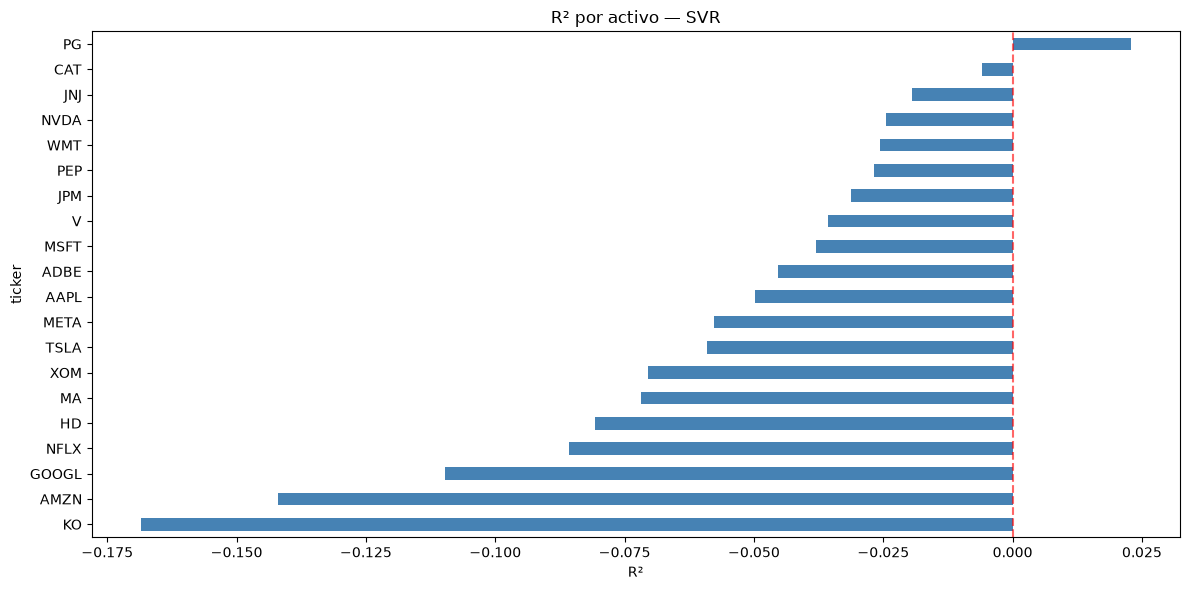

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df["R2"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0, color="red", linestyle="--", alpha=0.6)
ax.set_title("R² por activo — SVR")
ax.set_xlabel("R²")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_r2_por_activo.png", dpi=300, bbox_inches="tight")
plt.show()


## Predicho vs. real — ejemplo visual (2-3 activos)

Para inspeccionar cualitativamente qué tan bien sigue el modelo al retorno real, más allá de la métrica agregada.

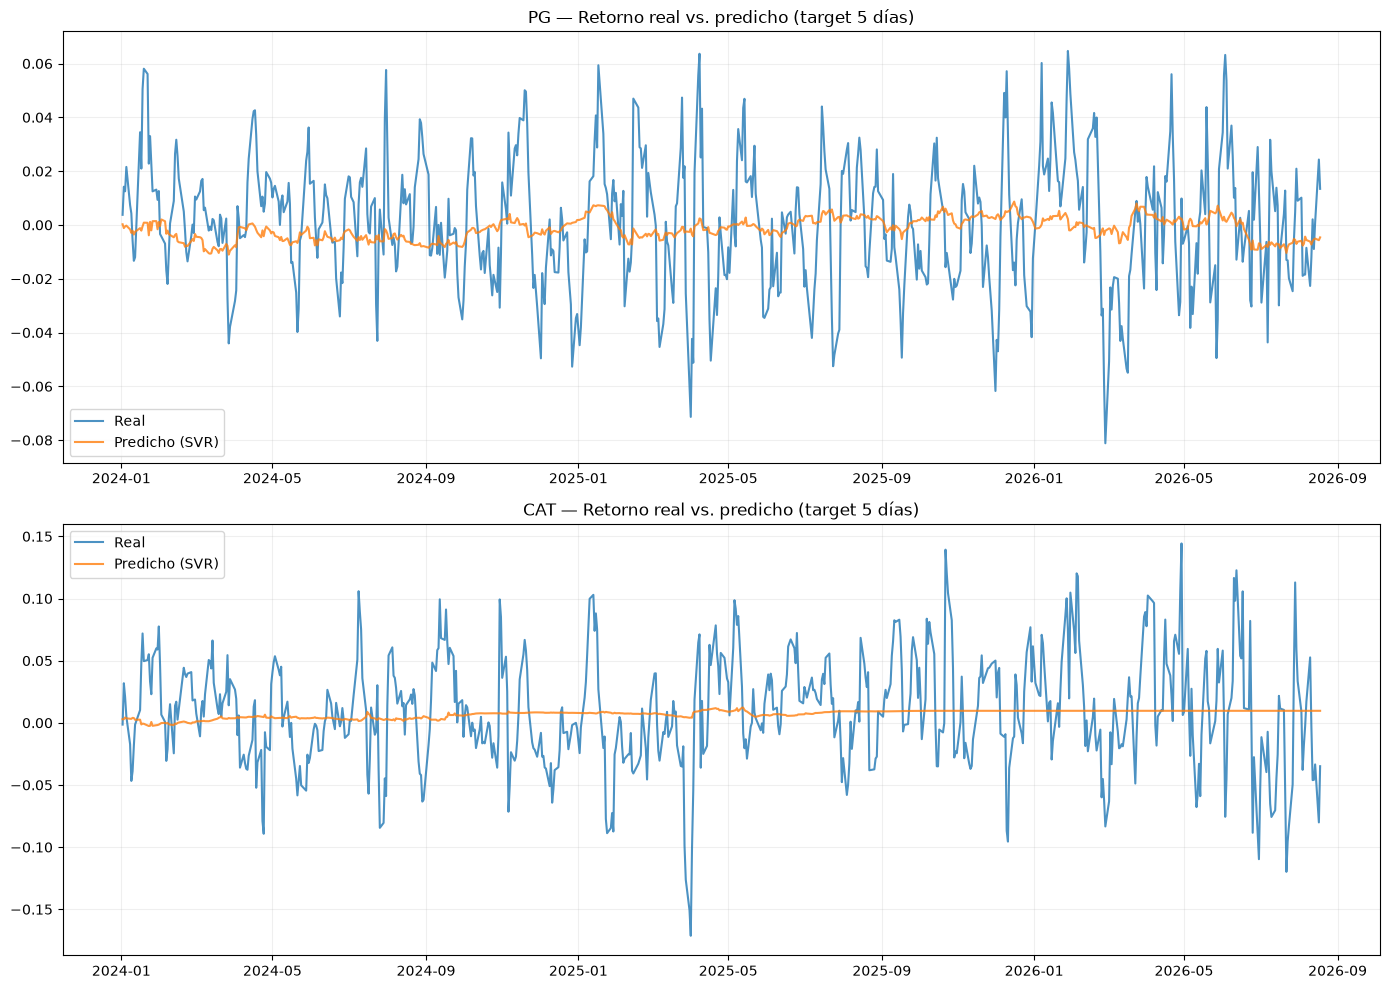

In [8]:
example_tickers = results_df.sort_values("R2", ascending=False).index[:2].tolist()

fig, axes = plt.subplots(len(example_tickers), 1, figsize=(14, 5 * len(example_tickers)))

if len(example_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers):
    pred_df = predictions[ticker]
    ax.plot(pred_df["Date"], pred_df["actual"], label="Real", alpha=0.8)
    ax.plot(pred_df["Date"], pred_df["predicted"], label="Predicho (SVR)", alpha=0.8)
    ax.set_title(f"{ticker} — Retorno real vs. predicho (target 5 días)")
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_predicho_vs_real.png", dpi=300, bbox_inches="tight")
plt.show()


## Vector de retornos esperados (mu) predicho por SVR

Este es el insumo que reemplaza al `mu` histórico usado en Markowitz (Fase 5). Se calcula como el promedio de las predicciones del modelo en el conjunto de test, anualizado por **capitalización compuesta** (no multiplicación lineal), igual que hace internamente PyPortfolioOpt — así se evita amplificar de forma irreal cualquier sesgo pequeño de la predicción. El benchmark (`^GSPC`) se excluye porque Markowitz no invierte en el índice, solo lo usa como referencia.

In [9]:
PERIODS_PER_YEAR = 252 / 5  # el target es un retorno de 5 días

mu_svr = {}

for ticker, pred_df in predictions.items():
    mean_5d_return = pred_df["predicted"].mean()
    mu_svr[ticker] = (1 + mean_5d_return) ** PERIODS_PER_YEAR - 1

mu_svr = pd.Series(mu_svr, name="mu_svr").sort_values(ascending=False)

mu_svr


NVDA     0.700822
ADBE     0.520513
V        0.455598
CAT      0.429750
MA       0.391004
MSFT     0.269567
JPM      0.249580
PEP      0.235240
WMT      0.074228
JNJ      0.026584
PG      -0.068579
AAPL    -0.091583
GOOGL   -0.155250
NFLX    -0.157616
TSLA    -0.169779
XOM     -0.201264
META    -0.207879
KO      -0.213053
HD      -0.339324
AMZN    -0.360617
Name: mu_svr, dtype: float64

### Comparación: mu histórico (Fase 5) vs. mu predicho por SVR

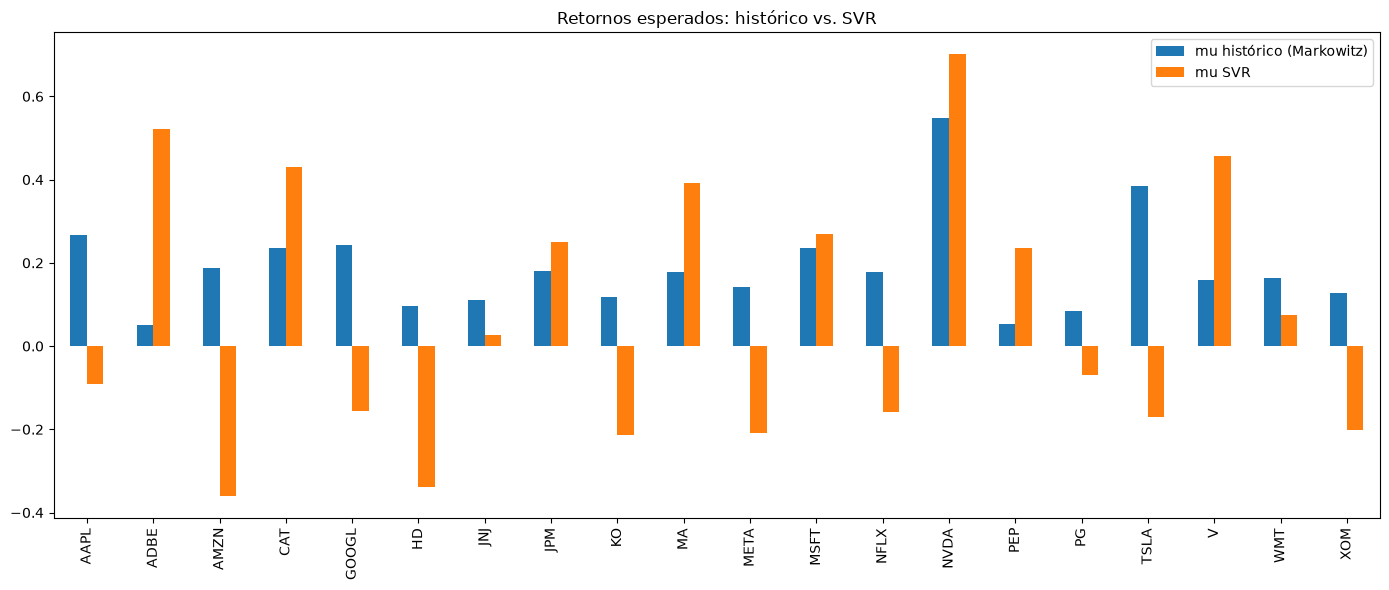

,mu histórico (Markowitz),mu SVR
AAPL,0.2667,-0.0916
ADBE,0.0513,0.5205
AMZN,0.1868,-0.3606
CAT,0.2356,0.4297
GOOGL,0.2430,-0.1553
HD,0.0966,-0.3393
JNJ,0.1111,0.0266
JPM,0.1802,0.2496
KO,0.1182,-0.2131
MA,0.1790,0.3910


In [10]:
from pypfopt.expected_returns import mean_historical_return

prices_for_mu = pd.read_csv(DATA_DIR / "adjusted_prices.csv", index_col=0, parse_dates=True)
asset_prices_svr = prices_for_mu.drop(columns=[benchmark])

mu_historical = mean_historical_return(asset_prices_svr)

mu_comparison = pd.DataFrame({
    "mu histórico (Markowitz)": mu_historical,
    "mu SVR": mu_svr
})

mu_comparison.plot(kind="bar", figsize=(14, 6), title="Retornos esperados: histórico vs. SVR")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_mu_historico_vs_svr.png", dpi=300, bbox_inches="tight")
plt.show()

mu_comparison.round(4)


## Guardar resultados

In [11]:
results_df.to_csv(RESULTS_DIR / "svr_performance_by_ticker.csv")
mu_svr.to_csv(RESULTS_DIR / "mu_svr.csv")

for ticker, pred_df in predictions.items():
    pred_df.to_csv(RESULTS_DIR / f"predictions_{ticker}.csv", index=False)

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\svr


## 10. Portafolio de Markowitz usando mu_svr (Opción 1: cuantificar el impacto)

Se corre la misma optimización de Máximo Sharpe de la Fase 5, pero reemplazando el `mu` histórico por `mu_svr`. El objetivo es cuantificar qué tan bien (o mal) le habría ido a un inversionista que hubiera confiado en las predicciones de SVR, comparado contra Markowitz clásico, Equal Weight y el S&P 500.

In [12]:
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier

MAX_WEIGHT = 0.15  # misma restricción usada en la Fase 5, para comparar en igualdad de condiciones

S_shrink_svr = CovarianceShrinkage(asset_prices_svr).ledoit_wolf()

ef_svr = EfficientFrontier(mu_svr, S_shrink_svr, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_svr.add_constraint(lambda w: w >= 0.01)
raw_weights_svr = ef_svr.max_sharpe(risk_free_rate=0.02)
weights_svr = ef_svr.clean_weights()

perf_svr = ef_svr.portfolio_performance(verbose=True, risk_free_rate=0.02)

pd.Series(weights_svr).sort_values(ascending=False)


Expected annual return: 38.1%
Annual volatility: 21.3%
Sharpe Ratio: 1.70


NVDA     0.15000
ADBE     0.15000
V        0.15000
CAT      0.15000
JPM      0.15000
MA       0.09303
MSFT     0.02697
PEP      0.01000
WMT      0.01000
JNJ      0.01000
PG       0.01000
AAPL     0.01000
GOOGL    0.01000
NFLX     0.01000
TSLA     0.01000
XOM      0.01000
META     0.01000
KO       0.01000
HD       0.01000
AMZN     0.01000
dtype: float64

In [13]:
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier

MAX_WEIGHT = 0.1  # misma restricción usada en la Fase 5, para comparar en igualdad de condiciones

S_shrink_svr_t = CovarianceShrinkage(asset_prices_svr).ledoit_wolf()

ef_svr_t = EfficientFrontier(mu_svr, S_shrink_svr_t, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_svr_t.add_constraint(lambda w: w >= 0.01)
raw_weights_svr_t = ef_svr_t.max_sharpe(risk_free_rate=0.02)
weights_svr_t = ef_svr_t.clean_weights()

perf_svr_t = ef_svr_t.portfolio_performance(verbose=True, risk_free_rate=0.02)

pd.Series(weights_svr_t).sort_values(ascending=False)

Expected annual return: 31.3%
Annual volatility: 19.8%
Sharpe Ratio: 1.48


NVDA     0.10
ADBE     0.10
V        0.10
CAT      0.10
MA       0.10
MSFT     0.10
JPM      0.10
PEP      0.10
WMT      0.09
JNJ      0.01
PG       0.01
AAPL     0.01
GOOGL    0.01
NFLX     0.01
TSLA     0.01
XOM      0.01
META     0.01
KO       0.01
HD       0.01
AMZN     0.01
dtype: float64

### Backtest: Markowitz+SVR vs. Markowitz clásico, Equal Weight y S&P 500

Mismo periodo y misma lógica de backtest de pesos fijos sin rebalanceo que en la Fase 5, para que la comparación sea justa.

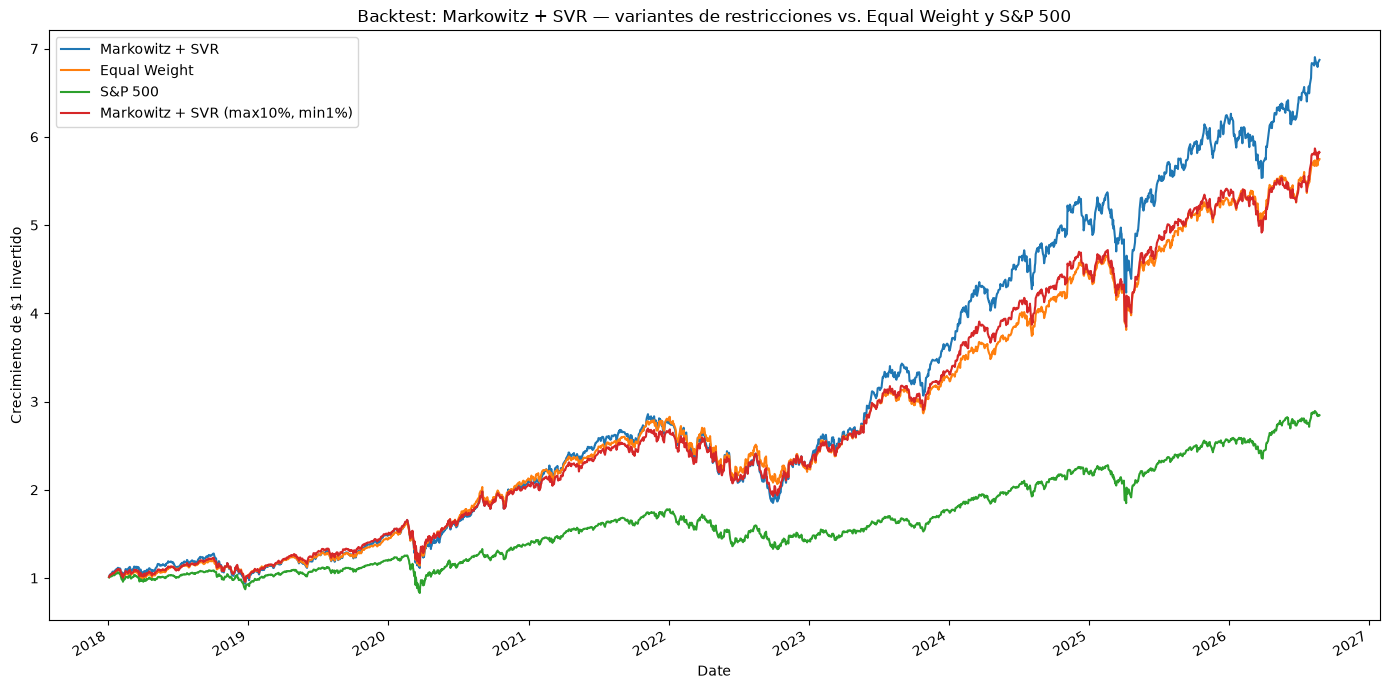

In [14]:
returns_for_backtest = pd.read_csv(DATA_DIR / "daily_returns.csv", index_col=0, parse_dates=True)
returns_for_backtest.index.name = "Date"
returns_for_backtest_clean = returns_for_backtest.dropna(how="all")

asset_returns_svr = returns_for_backtest_clean.drop(columns=[benchmark])

def portfolio_cumulative_return(weights: pd.Series, returns: pd.DataFrame) -> pd.Series:
    aligned_weights = weights.reindex(returns.columns).fillna(0)
    portfolio_returns = (returns * aligned_weights).sum(axis=1)
    return (1 + portfolio_returns).cumprod()

n_assets = len(asset_returns_svr.columns)
weights_equal_svr = pd.Series(1 / n_assets, index=asset_returns_svr.columns)

comparison_svr = pd.DataFrame({
    "Markowitz + SVR": portfolio_cumulative_return(pd.Series(weights_svr), asset_returns_svr),
    "Equal Weight": portfolio_cumulative_return(weights_equal_svr, asset_returns_svr),
    "S&P 500": (1 + returns_for_backtest_clean[benchmark]).cumprod()
})

# Agregar la variante (MAX_WEIGHT=0.10 + cota mínima 1%) a la comparación existente

comparison_svr["Markowitz + SVR (max10%, min1%)"] = portfolio_cumulative_return(
    pd.Series(weights_svr_t), asset_returns_svr
)

comparison_svr.plot(figsize=(14, 7), title="Backtest: Markowitz + SVR — variantes de restricciones vs. Equal Weight y S&P 500")
plt.ylabel("Crecimiento de $1 invertido")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_backtest_markowitz_svr_variantes.png", dpi=300, bbox_inches="tight")
plt.show()


### Tabla de métricas comparativa (incluye Markowitz clásico de la Fase 5, para referencia manual)

Completa la fila "Markowitz clásico" con los valores que ya obtuviste en la Fase 5 (retorno 26.7%, vol 20.0%, Sharpe 1.24, drawdown -28.1%), para tener las cuatro estrategias en una sola tabla en tu informe.

In [15]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = 0.02) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown
    }

summary_svr = pd.DataFrame({
    col: annualized_metrics(comparison_svr[col]) for col in comparison_svr.columns
}).T

summary_svr.round(4)

,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Markowitz + SVR,0.2509,0.2407,0.9592,-0.3524
Equal Weight,0.2224,0.2025,0.9997,-0.2998
S&P 500,0.1392,0.1922,0.6201,-0.3392
"Markowitz + SVR (max10%, min1%)",0.2256,0.2116,0.9713,-0.2981


In [18]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = 0.02) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown
    }

summary_svr_t = pd.DataFrame({
    col: annualized_metrics(comparison_svr[col]) for col in comparison_svr.columns
}).T

summary_svr_t.round(4)

,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Markowitz + SVR,0.2509,0.2407,0.9592,-0.3524
Equal Weight,0.2224,0.2025,0.9997,-0.2998
S&P 500,0.1392,0.1922,0.6201,-0.3392
"Markowitz + SVR (max10%, min1%)",0.2256,0.2116,0.9713,-0.2981


### Guardar resultados de la Opción 1

In [ ]:
pd.Series(weights_svr).to_csv(RESULTS_DIR / "weights_markowitz_svr.csv")
comparison_svr.to_csv(RESULTS_DIR / "backtest_markowitz_svr.csv")
summary_svr.to_csv(RESULTS_DIR / "summary_markowitz_svr.csv")

print("Resultados de Markowitz+SVR guardados en:", RESULTS_DIR)


Resultados de Markowitz+SVR guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\svr
